In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt
import time
from jax import vmap
import sys
import jax

jax.config.update("jax_platform_name", "cpu")


sys.path.append("..")


# from utils.integrate import leggauss

In [2]:
from configuration.rte1d_settings import get_config

In [3]:
start_time = time.time()
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
kn = rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]


def fn_source(x):
    return 0.0


fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
num_x, num_v = rte_config.model.grid_sizes  # num_v % 2 == 0
print(f"num_x = {num_x}, num_v = {num_v}")
(xmin, xmax), (vmin, vmax) = domain["x"], domain["v"]
dx = (xmax - xmin) / num_x
kn_dx = kn / dx
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
# x, xc
# quadratures = leggauss(num_v)
# mesh_v, weights = quadratures
# mesh_v = mesh_v.squeeze()
# weights = weights.squeeze()
mesh_v = np.linspace(vmin, vmax, num_v)
weights = np.ones((num_v,)) * (vmax - vmin) / (num_v - 1)
v_pos = mesh_v[mesh_v > 0]
v_neg = mesh_v[mesh_v < 0]
vector_sigma_s = np.asarray(vmap(fn_sigma_s)(mesh_xc))[:, None]  # (num_x, 1)
vector_sigma_t = np.asarray(
    vmap(fn_sigma_s)(mesh_xc)[:, None]
    + kn**2 * vmap(fn_sigma_a)(mesh_xc)[:, None]
)
vector_source = np.asarray(vmap(fn_source)(mesh_xc))[:, None]
matrix_f = np.ones((num_x + 1, num_v))
matrix_fc = np.zeros((num_x, num_v))
matrix_f[0, mesh_v > 0] = np.asarray(vmap(fn_l)(v_pos))
matrix_f[-1, mesh_v < 0] = np.asarray(vmap(fn_r)(v_neg))

num_x = 1024, num_v = 2048


In [4]:
def compute_q(matrix_f, weights, vector_sigma_s, vector_source, kn):
    matrix_fc = 0.5 * (matrix_f[1:] + matrix_f[:-1])  # shape (num_x, num_v)
    avg = 0.5 * matrix_fc @ weights[:, None]  # shape (num_x, 1)
    q = vector_sigma_s * avg + kn**2 * vector_source  # shape (num_x, num_v)
    return q

In [5]:
def source_iteration(matrix_f):
    F = matrix_f.copy()
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(-1, -num_x - 1, -1):
        F[i - 1, mesh_v < 0] = (
            q[i] / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            - (0.5 * vector_sigma_t[i, 0] + kn_dx * v_neg)
            / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            * F[i, mesh_v < 0]
        )
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(num_x):
        F[i + 1, mesh_v > 0] = (
            q[i] / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            - (0.5 * vector_sigma_t[i, 0] - kn_dx * v_pos)
            / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            * F[i, mesh_v > 0]
        )
    return F

In [6]:
def dvm_solver(
    matrix_f: np.array, tol: float = 1e-5, max_iter: int = 2**14
) -> np.array:
    for i in range(max_iter):
        matrix_f_new = source_iteration(matrix_f)
        diff = np.linalg.norm(matrix_f_new - matrix_f)
        print(f"Iter: {i}, difference = {diff:.4e}")
        if diff < tol:
            print(f"converged at iter {i}")
            break
        matrix_f = matrix_f_new
    return matrix_f

In [7]:
matrix_f = dvm_solver(matrix_f)
end_time = time.time()
print(f"time taken: {end_time - start_time} seconds")

Iter: 0, difference = 5.1161e+02
Iter: 1, difference = 2.1233e+02
Iter: 2, difference = 1.0666e+02
Iter: 3, difference = 5.4744e+01
Iter: 4, difference = 2.8192e+01
Iter: 5, difference = 1.4583e+01
Iter: 6, difference = 7.5716e+00
Iter: 7, difference = 3.9385e+00
Iter: 8, difference = 2.0500e+00
Iter: 9, difference = 1.0671e+00
Iter: 10, difference = 5.5550e-01
Iter: 11, difference = 2.8915e-01
Iter: 12, difference = 1.5051e-01
Iter: 13, difference = 7.8339e-02
Iter: 14, difference = 4.0776e-02
Iter: 15, difference = 2.1224e-02
Iter: 16, difference = 1.1047e-02
Iter: 17, difference = 5.7500e-03
Iter: 18, difference = 2.9929e-03
Iter: 19, difference = 1.5578e-03
Iter: 20, difference = 8.1085e-04
Iter: 21, difference = 4.2205e-04
Iter: 22, difference = 2.1968e-04
Iter: 23, difference = 1.1434e-04
Iter: 24, difference = 5.9516e-05
Iter: 25, difference = 3.0978e-05
Iter: 26, difference = 1.6124e-05
Iter: 27, difference = 8.3926e-06
converged at iter 27
time taken: 4.939486980438232 seconds

In [8]:
X, V = np.meshgrid(mesh_x[1:-1], mesh_v[1:-1])
F = matrix_f.T[1:-1, 1:-1]

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


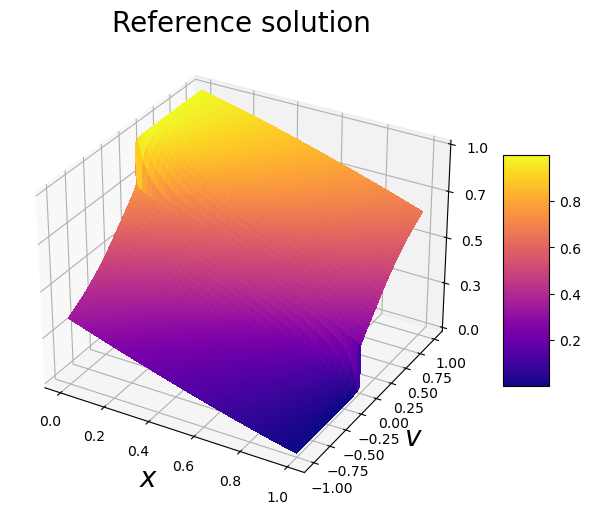

In [9]:
font_format = {"family": "Times New Roman", "size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(
    X, V, F, cmap="plasma", linewidth=0, antialiased=False
)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


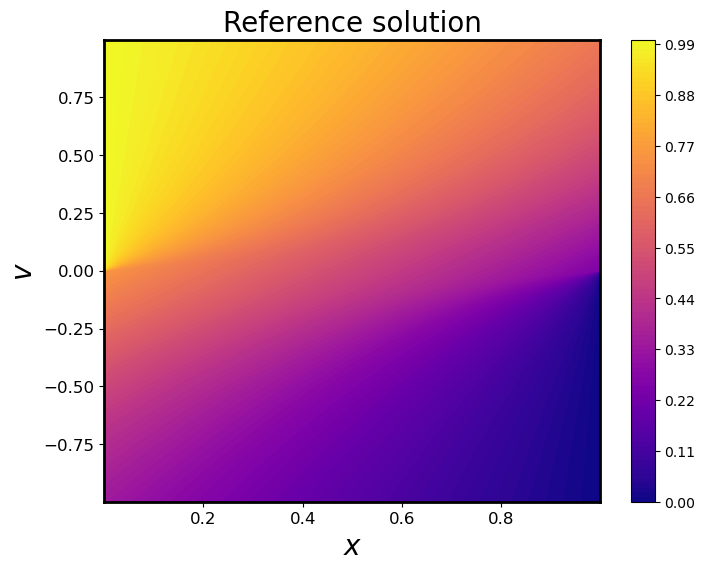

In [10]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [12]:
np.savez(
    f"../data/rte1d_ex2_ref_{kn:.1e}.npz",
    mesh_x=mesh_x[1:-1],
    mesh_v=mesh_v[1:-1],
    F=F,
)
kn

1.0